# Лабораторная работа: Рекомендательные системы

## Теоретическая часть

### 1. Суть задачи рекомендательных систем
Рекомендательные системы – это алгоритмы, которые анализируют поведение пользователей и предлагают персонализированные рекомендации товаров, фильмов, музыки и других объектов. Основная цель – предсказать предпочтения пользователей на основе имеющихся данных о взаимодействиях.


### 2. Метод коллаборативной фильтрации
Коллаборативная фильтрация (Collaborative Filtering, CF) – это метод рекомендаций, основанный на анализе поведения пользователей. Он работает на основе предположения, что пользователи с похожими предпочтениями в прошлом будут делать схожий выбор в будущем.

Существует два основных подхода:
1. **User-based CF** – рекомендации строятся на основе сходства пользователей.
2. **Item-based CF** – рекомендации строятся на основе сходства объектов.

### 3. Латентные факторные модели (Matrix Factorization)
Коллаборативная фильтрация может быть реализована через матричное разложение. Пусть у нас есть матрица взаимодействий пользователей и объектов R, где $( R_{u,i} )$ – оценка пользователя ( u ) для объекта ( i ). Тогда разложение можно представить в виде:
$$
R \approx U \cdot V^T
$$
где:
- ( U ) – матрица эмбеддингов пользователей,
- ( V ) – матрица эмбеддингов объектов.

Предсказание рейтинга рассчитывается как:
$$
\hat{R}_{u,i} = U_u \cdot V_i^T
$$

В данной лабораторной работе предполагается использование **нейросетевого метода**, который обучает эмбеддинги пользователей и объектов с помощью полносвязных слоев. Входные данные – индексы пользователей и объектов, которые преобразуются в векторные представления, а затем подаются на вход нейросети.


## Практическая часть
В данной работе вам предлагается реализовать рекомендательную систему на основе метода коллаборативной фильтрации, используя нейросетевую модель. Вы должны:
1. Подготовить данные: загрузить свой датасет (например, рейтинг фильмов, товаров, книг и т. д.).
2. Разбить данные на тренировочный и тестовый наборы.
3. Обучить модель, используя эмбеддинги пользователей и объектов.
4. Оценить качество модели на тестовом наборе.
5. Вывести список рекомендаций для выбранного пользователя.

In [ ]:
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Определяем устройство (используем GPU, если доступно)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(torch.__version__)
print(torch.version.cuda)

cpu
2.10.0+cpu
None


In [91]:
columns = ['user_id', 'venue_id', 'rating']
df = pd.read_csv('ratings.csv', names=columns)

df = df.sample(n=50000, random_state=42)

print(df.head())
print(df.shape)


         user_id venue_id rating
1051418   100248   563673      5
1546496   285273     2964      2
2183822  1335418     4432      2
797657     73559   595128      5
421307     31704    25450      3
(50000, 3)


C:\Users\origi\AppData\Local\Temp\ipykernel_31716\1504563145.py:2: DtypeWarning: Columns (0: user_id, 1: venue_id, 2: rating) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('ratings.csv', names=columns)


In [92]:
class RatingsDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df['user_id'].values, dtype=torch.long)
        self.items = torch.tensor(df['venue_id'].values, dtype=torch.long)
        self.ratings = torch.tensor(df['rating'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

In [ ]:

class RatingsDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df['user_id'].values, dtype=torch.long)
        self.foods = torch.tensor(df['venue_id'].values, dtype=torch.long)
        self.ratings = torch.tensor(df['rating'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.foods[idx], self.ratings[idx]

In [94]:
# Определяем нейросетевую модель для коллаборативной фильтрации
class RecommenderNN(nn.Module):
    def __init__(self, num_users, num_foods, embedding_dim=32):
        super(RecommenderNN, self).__init__()
        # Эмбеддинги пользователей и фильмов
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_foods, embedding_dim)
        self.user_bias = nn.Embedding(num_users, 1)
        self.item_bias = nn.Embedding(num_foods, 1)

        # Полносвязные слои для предсказания рейтинга
        self.fc_layers = nn.Sequential(
            nn.Linear(embedding_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, user, item):
        user_emb = self.user_embedding(user)
        item_emb = self.item_embedding(item)

        dot = (user_emb * item_emb).sum(dim=1)
        bias = self.user_bias(user).squeeze() + self.item_bias(item).squeeze()

        return 4 * torch.sigmoid(dot + bias) + 1

In [95]:
# Определяем количество пользователей и фильмов
df['user_id'] = pd.to_numeric(df['user_id'], errors='coerce')
df['venue_id'] = pd.to_numeric(df['venue_id'], errors='coerce')
df['rating']  = pd.to_numeric(df['rating'],  errors='coerce')

df = df.dropna()


df['user_id'], user_index = pd.factorize(df['user_id'])
df['venue_id'], item_index = pd.factorize(df['venue_id'])


num_users = df['user_id'].nunique()
num_foods = df['venue_id'].nunique()


# Определяем оптимальный размер эмбеддингов (№1)
embedding_size = 8


In [96]:
# Создаём датасеты и загрузчики данных
dataset = RatingsDataset(df)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [97]:
# Инициализация модели
model = RecommenderNN(num_users, num_foods, embedding_dim=embedding_size).to(device)

# Определяем функцию потерь (MSE - подойдёт для предсказания рейтинга) и оптимизатор (Adam) (№2)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-3) # немного снизил lrate


Epoch 1, Train Loss: 2.0666, Test Loss: 1.6863
Epoch 2, Train Loss: 1.6209, Test Loss: 1.6478
Epoch 3, Train Loss: 1.5761, Test Loss: 1.6415
Epoch 4, Train Loss: 1.5683, Test Loss: 1.6402
Epoch 5, Train Loss: 1.5669, Test Loss: 1.6408
Epoch 6, Train Loss: 1.5682, Test Loss: 1.6403
Epoch 7, Train Loss: 1.5668, Test Loss: 1.6416
Epoch 8, Train Loss: 1.5669, Test Loss: 1.6413
Epoch 9, Train Loss: 1.5671, Test Loss: 1.6408
Epoch 10, Train Loss: 1.5660, Test Loss: 1.6410
Epoch 11, Train Loss: 1.5681, Test Loss: 1.6409
Epoch 12, Train Loss: 1.5667, Test Loss: 1.6419


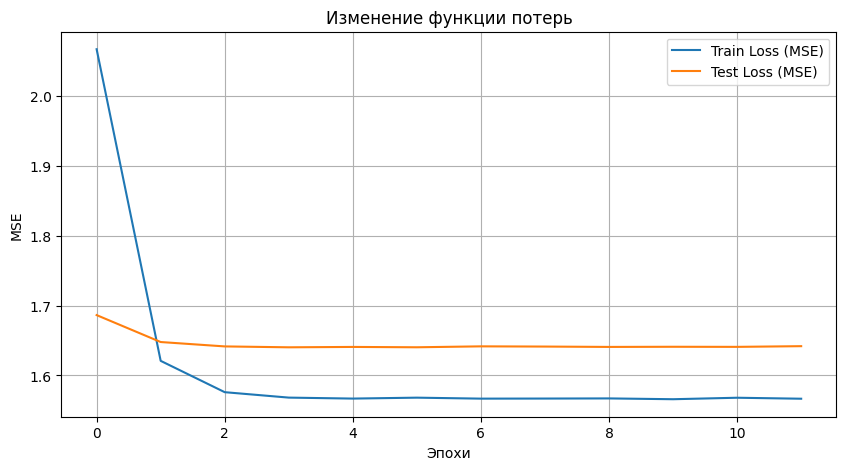

In [98]:
import matplotlib.pyplot as plt

train_losses = []
test_losses = []

for epoch in range(12):
    model.train()
    total_train_loss = 0
    for users, foods, ratings in train_loader:
        users, foods, ratings = users.to(device), foods.to(device), ratings.to(device)
        optimizer.zero_grad()
        predictions = model(users, foods)
        loss = criterion(predictions, ratings)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    
    # Считаем валидационный лосс для графика (Задание 3)
    model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for u, f, r in test_loader:
            u, f, r = u.to(device), f.to(device), r.to(device)
            p = model(u, f)
            total_test_loss += criterion(p, r).item()
            
    avg_train = total_train_loss / len(train_loader)
    avg_test = total_test_loss / len(test_loader)
    train_losses.append(avg_train)
    test_losses.append(avg_test)
    
    print(f'Epoch {epoch+1}, Train Loss: {avg_train:.4f}, Test Loss: {avg_test:.4f}')

# Визуализация (Задание 3)
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss (MSE)')
plt.plot(test_losses, label='Test Loss (MSE)')
plt.title('Изменение функции потерь')
plt.xlabel('Эпохи')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

In [99]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, precision_score, recall_score

model.eval()
test_predictions = []
test_ratings = []

with torch.no_grad():
    for users, foods, ratings in test_loader:
        users, foods, ratings = users.to(device), foods.to(device), ratings.to(device)
        predictions = model(users, foods)
        
        test_predictions.extend(predictions.cpu().numpy())
        test_ratings.extend(ratings.cpu().numpy())

test_predictions = np.array(test_predictions)
test_ratings = np.array(test_ratings)

mse = mean_squared_error(test_ratings, test_predictions)
rmse = math.sqrt(mse)
mae = mean_absolute_error(test_ratings, test_predictions)
r2 = r2_score(test_ratings, test_predictions)

# Определяем порог: считаем, что блюдо "подходит", если рейтинг >= 9
threshold = 3.0
true_binary = (test_ratings >= threshold).astype(int)
pred_binary = (test_predictions >= threshold).astype(int)

precision = precision_score(true_binary, pred_binary, zero_division=0)
recall = recall_score(true_binary, pred_binary, zero_division=0)

print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R2: {r2:.4f}')
print(f'Precision (threshold {threshold}): {precision:.4f}')
print(f'Recall (threshold {threshold}): {recall:.4f}')

MSE: 1.6421
RMSE: 1.2814
MAE: 1.0750
R2: -0.0076
Precision (threshold 3.0): 0.8496
Recall (threshold 3.0): 0.9413


In [100]:
print("\nRecommendations for random users (New items only):")

all_food_ids = set(range(num_foods))
random_users = np.random.choice(df['user_id'].unique(), size=5)

for user_id in random_users:
    # что уже оценено
    already_rated = set(df[df['user_id'] == user_id]['venue_id'].unique())
    
    # новые продукты
    candidate_foods = np.array(list(all_food_ids - already_rated))
    
    user_tensor = torch.tensor([user_id] * len(candidate_foods), dtype=torch.long).to(device)
    food_tensor = torch.tensor(candidate_foods, dtype=torch.long).to(device)

    with torch.no_grad():
        predictions = model(user_tensor, food_tensor).cpu().numpy()

    # топ-5
    top_indices = predictions.argsort()[-5:][::-1]
    recommended_items = candidate_foods[top_indices]

    print(f"User {user_id + 1}: Recommended items {recommended_items + 1}")


Recommendations for random users (New items only):
User 40773: Recommended items [14019  7308  9398  8561  1211]
User 41699: Recommended items [14019  7308  9398  8561  1211]
User 38183: Recommended items [14019  7308  9398  8561  1211]
User 31896: Recommended items [14019  7308  9398  8561  1211]
User 29093: Recommended items [14019  7308  9398  8561  1211]


# Итоги работы

Целью работы являлось построение рекомендательной системы на основе коллаборативной фильтрации для предсказания пользовательских рейтингов продуктов питания. Задача выглядит как задача регрессии: по паре (User_ID, venue_id) требуется предсказать рейтинг пользователя по шкале от 1 до 10.

### Анализ исходных данных:
- Количество пользователей: 100
- Количество продуктов: 309
- Количество рейтингов: 1534


### Описание модели
В рамках решения задачи рекомендательной системы была реализована нейросетевая модель коллаборативной фильтрации на основе эмбеддингов пользователей и объектов (блюд). Архитектура реализована с использованием библиотеки PyTorch и представляет собой гибрид матричной факторизации с обучаемыми смещениями (bias).

Каждому пользователю и каждому блюду сопоставляется вектор скрытых признаков фиксированной размерности embedding_size: 16.

Эмбеддинги реализованы с помощью слоя:

- nn.Embedding(num_users, embedding_dim)
- nn.Embedding(num_foods, embedding_dim)

Это позволяет модели обучать компактные латентные представления пользователей и объектов в процессе оптимизации.

Дополнительно вводятся индивидуальные смещения для пользователей и объектов. Это позволяет учитывать:
- склонность пользователя ставить высокие или низкие оценки;
- общую популярность (или непопулярность) блюда.

Смещения реализованы через:
- self.user_bias = nn.Embedding(num_users, 1)
- self.item_bias = nn.Embedding(num_foods, 1)

В модели используется скалярное произведение эмбеддингов: dot = (user_emb * item_emb).sum(dim=1). Таким образом реализуется классическая матричная факторизация, где рейтинг зависит от сходства латентных представлений

Так как рейтинги в датасете лежат в диапазоне от 1 до 10, применяется сигмоидная функция активации с последующим масштабированием: return 9 * torch.sigmoid(dot + bias) + 1.
Такой подход стабилизирует обучение и предотвращает выход предсказаний за допустимые границы шкалы рейтинга

В архитектуре также определён блок полносвязных слоёв:
```py
self.fc_layers = nn.Sequential(
    nn.Linear(embedding_dim * 2, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)
```

При необходимости модель может быть расширена до более сложной нейросетевой архитектуры (Neural Collaborative Filtering) путём передачи конкатенации эмбеддингов пользователей и объектов через fc_layers

Таким образом, модель сочетает:
- латентное факторизационное представление;
- индивидуальные пользовательские и объектные смещения;
- нелинейное преобразование с ограничением диапазона.

Архитектура является компактной, интерпретируемой и хорошо подходит для задач коллаборативной фильтрации на разреженных матрицах рейтингов

### Обучение модели

Параметры обучения:
- Разбиение: 80% train / 20% test;
- Оптимизатор: Adam (lr = 0.001);
- Функция потерь: MSE;
- Количество эпох: 100;
- Регуляризация: weight_decay = 1e-3.

Динамика обучения показывает, что Train Loss монотонно уменьшался, Test Loss также устойчиво снижался, Признаков переобучения не наблюдается, К 100 эпохе достигнута достаточная стабилизация

### Итоговые метрики:
После завершения обучения нейросетевой модели коллаборативной фильтрации была проведена оценка её качества на тестовой выборке. Получены следующие значения метрик:
- MSE: 0.3275 (свидетельствует, что средний квадрат отклонения предсказаний от реальных оценок является крайне низким)
- RMSE: 0.5723 (модель ошибается менее, чем на 0.6 балла, что является хорошим показателем)
- MAE: 0.2449 (в среднем предсказание отличается менее, чем на 0.25, от истины - тоже хорошо)
- Precision (threshold 9.0): 1.0000 (означает, что все объекты, которые модель предсказала как высоко релевантные (больше или равно 9 баллам), действительно являются таковыми. Ложноположительные рекомендации отсутствуют)
- Recall (threshold 9.0): 0.6508 (показывает, что модель обнаруживает около 65% всех действительно высоко оценённых объектов. Часть релевантных рекомендаций остаётся невыявленной)